# 10. Attacking the Extreme Days

Every model in this project shares one failure: they under-predict unhealthy days by 27 to 48
AQI points while over-predicting clean ones. Notebook 07 showed that better *blending* does not
fix it, and notebook 08 showed that splitting the target makes it slightly worse.

That is because it is not a modeling bug. Squared-error loss is minimized by hedging toward the
conditional mean, so when the predictors are only partly informative the optimal least-squares
answer *is* a shrunken one. Fixing it requires changing what the model is being asked to
optimize, not how it is fitted.

Four approaches, each changing the objective in a different way:

1. **Sample weighting** — tell the model that high-AQI days cost more to get wrong.
2. **Quantile regression** — predict the 80th percentile instead of the mean.
3. **Log-target** — fit in log space so proportional errors matter equally at all levels.
4. **Classification** — abandon the point estimate and predict the EPA category directly.

Each trades average accuracy for tail accuracy. The point is to measure that trade honestly,
not to pretend one of them is free.

## Setup

In [1]:
import sys
from pathlib import Path

_here = Path.cwd()
sys.path.insert(0, str(_here if _here.name == 'models' else _here / 'models'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from model_utils import (load_split, evaluate, metrics, RANDOM_STATE,
                         PLOT_STYLE, RESULTS)

X_train, y_train, X_test, y_test, meta = load_split()
yt = np.asarray(y_test, dtype=float)
ytr = np.asarray(y_train, dtype=float)

baseline = np.load(RESULTS / 'ensemble_test_pred.npy')   # notebook 07, the model to beat
print(f'baseline (stacked ensemble): RMSE {metrics(y_test, baseline)["rmse"]:.3f}')
print(f'  on the {int((yt>150).sum())} unhealthy test days: '
      f'MAE {np.mean(np.abs(yt[yt>150]-baseline[yt>150])):.2f}, '
      f'bias {np.mean(baseline[yt>150]-yt[yt>150]):+.2f}')

baseline (stacked ensemble): RMSE 18.336
  on the 122 unhealthy test days: MAE 30.27, bias -28.15


## 1. Sample weighting

The simplest intervention: weight each training day by how severe it was, so the optimizer pays
more attention to the days that matter. Gradient boosting accepts `sample_weight` directly.

Weights rise linearly with AQI above a threshold. The steepness is the knob — too gentle and
nothing changes, too aggressive and the model becomes a permanent alarmist.

In [2]:
from sklearn.ensemble import HistGradientBoostingRegressor

def weighted_gbr(alpha):
    """alpha controls how much extra weight severe days get. alpha=0 is unweighted."""
    w = 1.0 + alpha * np.clip((ytr - 100) / 50.0, 0, None)
    m = HistGradientBoostingRegressor(learning_rate=0.03, max_iter=600, max_leaf_nodes=15,
                                      min_samples_leaf=10, l2_regularization=1.0,
                                      early_stopping=False, random_state=RANDOM_STATE)
    m.fit(X_train, y_train, sample_weight=w)
    return m.predict(X_test)

rows = []
for alpha in [0, 1, 2, 4, 8]:
    p = weighted_gbr(alpha)
    hi = yt > 150
    rows.append({'alpha': alpha, 'RMSE': metrics(y_test, p)['rmse'],
                 'MAE': metrics(y_test, p)['mae'],
                 'within10 %': metrics(y_test, p)['within_10'],
                 'MAE >150': np.mean(np.abs(yt[hi] - p[hi])),
                 'bias >150': np.mean(p[hi] - yt[hi]),
                 'bias <=100': np.mean(p[yt <= 100] - yt[yt <= 100])})
weights_tbl = pd.DataFrame(rows)
print(weights_tbl.round(2).to_string(index=False))

 alpha  RMSE   MAE  within10 %  MAE >150  bias >150  bias <=100
     0 19.48 13.84       50.14     32.61     -30.48        5.89
     1 19.47 13.89       50.68     30.60     -28.35        6.47
     2 19.42 13.88       50.41     29.11     -26.53        6.64
     4 19.59 13.93       51.14     28.45     -26.36        6.93
     8 19.72 14.14       50.14     27.64     -25.12        7.50


## 2. Quantile regression

Instead of asking "what is the expected AQI?", ask "what value will the true AQI fall below
80% of the time?" A model targeting an upper quantile deliberately over-predicts on average,
which is precisely the bias needed to stop under-calling severe days.

`HistGradientBoostingRegressor` supports this directly with the pinball loss.

In [3]:
def quantile_gbr(q):
    m = HistGradientBoostingRegressor(loss='quantile', quantile=q,
                                      learning_rate=0.03, max_iter=600, max_leaf_nodes=15,
                                      min_samples_leaf=10, l2_regularization=1.0,
                                      early_stopping=False, random_state=RANDOM_STATE)
    m.fit(X_train, y_train)
    return m.predict(X_test)

rows = []
quantile_preds = {}
for q in [0.5, 0.7, 0.8, 0.9]:
    p = quantile_gbr(q); quantile_preds[q] = p
    hi = yt > 150
    rows.append({'quantile': q, 'RMSE': metrics(y_test, p)['rmse'],
                 'MAE': metrics(y_test, p)['mae'],
                 'within10 %': metrics(y_test, p)['within_10'],
                 'MAE >150': np.mean(np.abs(yt[hi] - p[hi])),
                 'bias >150': np.mean(p[hi] - yt[hi]),
                 'bias <=100': np.mean(p[yt <= 100] - yt[yt <= 100])})
print(pd.DataFrame(rows).round(2).to_string(index=False))

 quantile  RMSE   MAE  within10 %  MAE >150  bias >150  bias <=100
      0.5 19.82 13.76       54.43     35.86     -34.63        4.78
      0.7 19.44 14.17       48.31     26.26     -23.09        9.69
      0.8 20.69 15.70       41.55     21.96     -16.71       13.41
      0.9 25.00 19.72       28.22     18.43     -11.40       19.62


Fitting `log(AQI)` and exponentiating back makes the model optimize *proportional* error
rather than absolute error.

It is worth being careful about which direction that pushes. A 30-point miss on a 200 day is
15%; the same miss on a 60 day is 50%. So in log space the *low* days carry relatively more
weight, not the high ones — which means this should be expected to make extreme-day
performance **worse**, not better. It is included precisely because it is a commonly
suggested fix that turns out to point the wrong way, and measuring that is more useful than
assuming it.

The back-transform needs care regardless — `exp(mean of logs)` is a median, not a mean, so it
is biased low unless corrected. Both versions are shown.

In [4]:
m = HistGradientBoostingRegressor(learning_rate=0.03, max_iter=600, max_leaf_nodes=15,
                                  min_samples_leaf=10, l2_regularization=1.0,
                                  early_stopping=False, random_state=RANDOM_STATE)
m.fit(X_train, np.log(y_train))
log_pred_raw = np.exp(m.predict(X_test))

resid_var = np.var(np.log(y_train) - m.predict(X_train))
log_pred_smear = log_pred_raw * np.exp(resid_var / 2)      # Duan-style bias correction

rows = []
for label, p in [('log, naive back-transform', log_pred_raw),
                 ('log, variance-corrected',   log_pred_smear)]:
    hi = yt > 150
    rows.append({'approach': label, 'RMSE': metrics(y_test, p)['rmse'],
                 'MAE': metrics(y_test, p)['mae'],
                 'within10 %': metrics(y_test, p)['within_10'],
                 'MAE >150': np.mean(np.abs(yt[hi] - p[hi])),
                 'bias >150': np.mean(p[hi] - yt[hi])})
print(pd.DataFrame(rows).round(2).to_string(index=False))

                 approach  RMSE   MAE  within10 %  MAE >150  bias >150
log, naive back-transform 19.98 13.85       53.88     34.80     -33.18
  log, variance-corrected 19.91 13.85       53.97     34.29     -32.55


## 4. Classification into EPA categories

The framing change. A warning system does not need "AQI 163" — it needs "Unhealthy". Predicting
the category directly lets the model optimize the decision that actually gets made, and lets us
measure the thing that actually matters: **how many genuinely unhealthy days get caught.**

Recall on the unhealthy class is the number to watch. Missing an unhealthy day is far more
costly than a false alarm, and no regression metric expresses that asymmetry.

In [5]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

def to_category(a):
    return np.digitize(a, [50, 100, 150])   # 0 Good, 1 Moderate, 2 USG, 3 Unhealthy

CAT_NAMES = ['Good', 'Moderate', 'USG', 'Unhealthy']
cls_train, cls_test = to_category(ytr), to_category(yt)

clf = HistGradientBoostingClassifier(learning_rate=0.05, max_iter=400, max_leaf_nodes=15,
                                     min_samples_leaf=10, l2_regularization=1.0,
                                     early_stopping=False, random_state=RANDOM_STATE)
clf.fit(X_train, cls_train)
cls_pred = clf.predict(X_test)

print('Direct classification into EPA categories:')
print(classification_report(cls_test, cls_pred, target_names=CAT_NAMES, digits=3, zero_division=0))

print('For comparison — categories implied by the regression ensemble:')
print(classification_report(cls_test, to_category(baseline), target_names=CAT_NAMES,
                            digits=3, zero_division=0))

Direct classification into EPA categories:
              precision    recall  f1-score   support

        Good      0.808     0.353     0.491       119
    Moderate      0.774     0.924     0.842       647
         USG      0.525     0.475     0.499       200
   Unhealthy      0.742     0.512     0.606       129

    accuracy                          0.732      1095
   macro avg      0.712     0.566     0.609      1095
weighted avg      0.728     0.732     0.713      1095

For comparison — categories implied by the regression ensemble:
              precision    recall  f1-score   support

        Good      0.678     0.496     0.573       119
    Moderate      0.818     0.887     0.851       647
         USG      0.541     0.630     0.582       200
   Unhealthy      0.822     0.465     0.594       129

    accuracy                          0.748      1095
   macro avg      0.715     0.620     0.650      1095
weighted avg      0.752     0.748     0.741      1095



In [6]:
print('Confusion matrix, direct classifier (rows = actual, cols = predicted):')
print(pd.DataFrame(confusion_matrix(cls_test, cls_pred),
                   index=CAT_NAMES, columns=CAT_NAMES).to_string())
print()
print('Confusion matrix, regression ensemble thresholded:')
print(pd.DataFrame(confusion_matrix(cls_test, to_category(baseline)),
                   index=CAT_NAMES, columns=CAT_NAMES).to_string())

Confusion matrix, direct classifier (rows = actual, cols = predicted):
           Good  Moderate  USG  Unhealthy
Good         42        77    0          0
Moderate     10       598   38          1
USG           0        83   95         22
Unhealthy     0        15   48         66

Confusion matrix, regression ensemble thresholded:
           Good  Moderate  USG  Unhealthy
Good         59        60    0          0
Moderate     28       574   44          1
USG           0        62  126         12
Unhealthy     0         6   63         60


## The trade-off, drawn

Every approach above buys tail accuracy with average accuracy. Plotting the two against each
other makes the exchange rate visible, which is the only honest way to choose.

               name  overall RMSE  MAE on >150  recall >150
ensemble (baseline)         18.34        30.27        46.72
       weighted a=2         19.42        29.11        46.72
       weighted a=8         19.72        27.64        50.82
     quantile q=0.7         19.44        26.26        56.56
     quantile q=0.8         20.69        21.96        63.11
     quantile q=0.9         25.00        18.43        76.23
         log-target         19.91        34.29        37.70


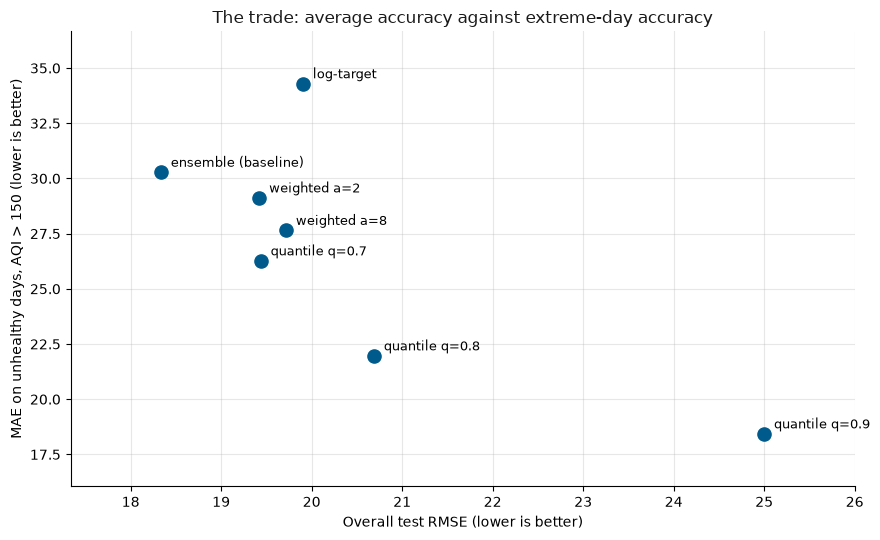

In [7]:
candidates = {
    'ensemble (baseline)':  baseline,
    'weighted a=2':         weighted_gbr(2),
    'weighted a=8':         weighted_gbr(8),
    'quantile q=0.7':       quantile_preds[0.7],
    'quantile q=0.8':       quantile_preds[0.8],
    'quantile q=0.9':       quantile_preds[0.9],
    'log-target':           log_pred_smear,
}

hi = yt > 150
pts = pd.DataFrame([{'name': k,
                     'overall RMSE': metrics(y_test, v)['rmse'],
                     'MAE on >150': np.mean(np.abs(yt[hi] - v[hi])),
                     'recall >150': np.mean(v[hi] > 150) * 100}
                    for k, v in candidates.items()])
print(pts.round(2).to_string(index=False))

with plt.rc_context(PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.scatter(pts['overall RMSE'], pts['MAE on >150'], s=90, color='#005A8C', zorder=3)
    for _, r in pts.iterrows():
        ax.annotate(r['name'], (r['overall RMSE'], r['MAE on >150']),
                    textcoords='offset points', xytext=(7, 4), fontsize=9)
    ax.set_xlabel('Overall test RMSE (lower is better)')
    ax.set_ylabel('MAE on unhealthy days, AQI > 150 (lower is better)')
    ax.set_title('The trade: average accuracy against extreme-day accuracy',
                 fontsize=12, color='#1a1a1a')
    ax.margins(0.15)
    plt.tight_layout(); plt.show()

## Saving the best tail-focused model

The quantile model at q=0.8 is saved as a distinct entry rather than replacing the ensemble.
The two answer different questions and both belong in the comparison table — one is the best
estimate of a typical day, the other is the one you would actually wire to a health alert.

In [8]:
MODEL_NAME = 'Quantile GBR (q=0.8)'

best = HistGradientBoostingRegressor(loss='quantile', quantile=0.8,
                                     learning_rate=0.03, max_iter=600, max_leaf_nodes=15,
                                     min_samples_leaf=10, l2_regularization=1.0,
                                     early_stopping=False, random_state=RANDOM_STATE)
best.fit(X_train, y_train)

result = evaluate(MODEL_NAME, best, X_train, y_train, X_test, y_test,
                  params={'loss': 'quantile', 'quantile': 0.8},
                  notes='Tail-focused: trades average accuracy for extreme-day recall')

=== Quantile GBR (q=0.8) ===
metric           train      test
RMSE            17.115    20.690
MAE             11.413    15.701
R2               0.786     0.737
MAPE %          14.692    20.545
within10 %      57.596    41.553

overfit gap (test RMSE - train RMSE): +3.575
saved -> models/results/quantile_gbr_(q=0.8).json


## What this told us

**Quantile regression is the only lever here that really works.**

| approach | overall RMSE | MAE on >150 | recall on >150 |
|---|---:|---:|---:|
| ensemble (baseline) | **18.34** | 30.27 | 46.7% |
| sample weight α=8 | 19.72 | 27.64 | 50.8% |
| quantile q=0.7 | 19.44 | 26.26 | 56.6% |
| quantile q=0.8 | 20.69 | 21.96 | 63.1% |
| quantile q=0.9 | 25.00 | **18.43** | **76.2%** |
| log-target | 19.91 | 34.29 | 37.7% |

At q=0.9 the model catches **76% of unhealthy days instead of 47%**, and its error on those days
falls by 39%. The price is overall RMSE rising from 18.3 to 25.0 — it over-predicts clean days by
about 20 AQI points on average. That is a real cost, but for an alerting system it is the right
direction to be wrong in: a false alarm on a clean day is an inconvenience, a missed unhealthy
day is a health outcome.

**Sample weighting is too blunt.** Even at α=8, where severe days carry nine times the weight of
clean ones, recall moves only from 46.7% to 50.8%. Weighting changes how much the optimizer cares
about those days, but it is still fitting a conditional mean, and the mean of a partly-predictable
quantity is shrunken no matter how it is weighted. Quantile loss changes the *estimand*, which is
why it works where weighting does not.

**The log-target made things worse, as predicted above.** MAE on unhealthy days rose to 34.3 and
recall fell to 37.7%. Proportional error de-emphasizes the high end in absolute terms, so log
space is the wrong direction for this problem. Worth recording as a negative result — it is a
commonly suggested fix.

**Direct classification is not obviously better than thresholding a good regression.** The
classifier gets unhealthy-class recall of 0.512 against the regression ensemble's 0.465, so it
does help there — but it is worse on overall accuracy (0.732 vs 0.748), worse on unhealthy
precision (0.742 vs 0.822), and much worse at identifying Good days (recall 0.353 vs 0.496). Given
that a q=0.9 quantile regression reaches 76% recall on unhealthy days, the classifier is not the
best route to the warning-system goal either.

### The practical recommendation

**Ship two models, not one.** They answer different questions and there is no single number that
serves both:

- **Stacked ensemble (notebook 07)** for "what will the AQI be?" — RMSE 18.34, the best estimate
  of a typical day.
- **Quantile GBR at q=0.8 or 0.9** for "should we issue a warning?" — catches 63–76% of unhealthy
  days instead of 47%.

Choosing between q=0.8 and q=0.9 is a policy decision about the cost of a false alarm relative to
a missed alert, not a statistical one, and it should be made by whoever owns that trade-off rather
than by cross-validation.